# UPSC Essay Writer

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langsmith import traceable
import os
import operator

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY") 

os.environ['LANGCHAIN_TRACING_V2']="true"
os.environ['LANGCHAIN_PROJECT']= "Langgraph_LangSmith"

In [3]:
load_dotenv()

True

In [4]:
api_key = os.getenv("GROQ_API_KEY")
model = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")

In [5]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Short feedback about the essay")
    score: float = Field(description="Score out of 10")

In [6]:
# Structured output = data in a clean, predictable format so both humans and programs can easily understand it
structured_model = model.with_structured_output(EvaluationSchema)

In [7]:
essay =  """

Globalization is something that is in the world. India is part of world and so India is affected by globalization. Many things happen because of globalization. Economy is change and people have jobs but also some people have no jobs. Some companies get money and some companies not get money. Trade is good and bad also. India exports many things and imports many things. Sometimes trade is nice and sometimes trade is not good because people lose jobs. Technology is also part of globalization. Internet and phones and computers are everywhere. People can talk to other countries but also people waste time. Culture is also change because of globalization. Some people learn good things and some people forget old things. Youth like foreign things and they not like old things. Education is affected too. Students see videos from other countries and they not learn properly in class. Health is affected because some people eat fast food and foreign food. Life style is also change. People are busy and stressed. Government tries to make rules but rules are not enough. Rich people get more money and poor people get less money. Inequality is problem. Globalization has many things. Some things are good and some things are bad. It is difficult to say if overall it is good or bad. People should think carefully. India should take good things from globalization and leave bad things. Many problems and many solutions are there but people not do properly. Overall, globalization is important but also many problems are there. People need to be careful and use it good. Country should do better and people should think more. There are many effects and impacts but it is difficult to write everything. Globalization is in India and it will continue. People should do their best. Life and economy and culture and society are changing. It is too much to explain but people should think about it. There are good things, bad things, happy things, sad things. People need to do better and change for future. India is part of world and it will face many things. Overall, globalization is something that is everywhere and people should be careful and think more and do better.

"""

In [ ]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}"
structured_model.invoke(prompt).feedback # or score

'The essay addresses the topic of globalization and its effects on India but lacks coherence, clarity, and depth in its arguments. The writer touches on various points but fails to provide concrete evidence or logical connections between ideas. The writing is descriptive but lacks analysis. The conclusion is somewhat confusing and does not effectively summarize the main points. The essay can benefit from more organization, precise language, and critical thinking. '

In [9]:
class UPSCstate(TypedDict):

    essay : str
    clarity_feedback : str
    analysis_feedback : str
    language_feedback : str
    individual_scores : Annotated[list[int], operator.add]
    overoll_feedback :str
    avg_score : float

In [10]:
@traceable(name="evalution_clarity_fn")
def evalution_clarity(state: UPSCstate):

    prompt = f"Evaluate the Clarity of Thought of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        'clarity_feedback' : output.feedback,
        'individual_scores' : [output.score]
    }


In [11]:
@traceable(name="evalution_analysis_fn")
def evalution_analysis(state: UPSCstate):

    prompt = f"Evaluate the Analysis the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        'analysis_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [12]:
@traceable(name="evalution_language_fn", tags=["dimension:language"], metadata={"dimension":"language"})
def evalution_language(state: UPSCstate):
    
    prompt = f"Evaluate the Analysis the following essay based on language and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {
        'language_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [13]:
@traceable(name="final_evalution_fn")
def final_evalution(state: UPSCstate):

    # summarize
    prompt = f"Based on the following feedback create a sumarized feedback \n clarity feedback - {state['clarity_feedback']} \n analysis feedback - {state['analysis_feedback']} \n language feedback - {state['language_feedback']}"
    overoll_feedback = model.invoke(prompt)

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {
        'overoll_feedback': overoll_feedback,
        'avg_score': avg_score
    }

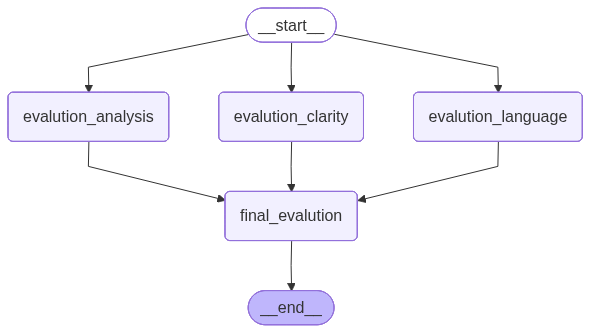

In [14]:
graph  = StateGraph(UPSCstate)

graph.add_node('evalution_clarity', evalution_clarity)
graph.add_node('evalution_analysis', evalution_analysis)
graph.add_node('evalution_language', evalution_language)
graph.add_node('final_evalution', final_evalution)

# edges

graph.add_edge(START, 'evalution_clarity')
graph.add_edge(START, 'evalution_analysis')
graph.add_edge(START, 'evalution_language')

graph.add_edge('evalution_clarity', 'final_evalution')
graph.add_edge('evalution_analysis', 'final_evalution')
graph.add_edge('evalution_language', 'final_evalution')

graph.add_edge('final_evalution', END)

workflow = graph.compile()
workflow

In [15]:
# initial_state = {
#     'essay' :essay
# }

# workflow.invoke(initial_state)

In [17]:
if __name__ == "__main__":
    result = workflow.invoke(
        {"essay": essay}#,
        # config={
        #     "run_name": "evaluate_upsc_essay",  # becomes root run name
        #     "tags": ["essay", "langgraph", "evaluation"],
        #     "metadata": {
        #         "essay_length": len(essay),
        #         "model": "gpt-4o-mini",
        #         "dimensions": ["language", "analysis", "clarity"],
        #     },
        # },
    )

    print("\n=== Evaluation Results ===")
    print("Language feedback:\n", result.get("language_feedback", ""), "\n")
    print("Analysis feedback:\n", result.get("analysis_feedback", ""), "\n")
    print("Clarity feedback:\n", result.get("clarity_feedback", ""), "\n")
    print("Overall feedback:\n", result.get("overall_feedback", ""), "\n")
    print("Individual scores:", result.get("individual_scores", []))
    print("Average score:", result.get("avg_score", 0.0))


=== Evaluation Results ===
Language feedback:
 The essay provides a good overview of the effects of globalization, but lacks depth and clarity in its analysis. The writer jumps between different ideas and does not provide a clear conclusion. There is a good attempt to discuss the positive and negative effects of globalization, but the writer could have explored these ideas further. The writing style is simple and lacks sophistication. Overall, the essay is a good start, but requires more development and refinement. 

Analysis feedback:
 The essay provides a general overview of the effects of globalization on India, but lacks depth and specific examples. It also contains some grammatical errors and simplistic statements. Overall, it is a good attempt but can be improved with more research and critical thinking. 

Clarity feedback:
 The essay has a clear structure and effectively expresses the author's point of view on the effects of globalization. However, the writing is simple and lac